# Essential libraries for analysis

In [12]:
# Suppress all warnings to ensure a clean output during execution

import warnings

warnings.filterwarnings("ignore")

In [13]:
# Libraries for data manipulation and computation
import pandas as pd  # Structured data in DataFrames
import numpy as np  # Numerical operations

# Libraries for data visualization
import matplotlib.pyplot as plt  # Basic visualizations
import seaborn as sns  # Advanced statistical visualizations
import matplotlib.colors as mcolors  # Color handling
from matplotlib import cm
# Libraries for model creation and evaluation
from sklearn.model_selection import train_test_split  # Split data for validation
from sklearn.linear_model import LogisticRegression  # Logistic Regression model
from sklearn.ensemble import RandomForestClassifier  # Random Forest model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Model performance metrics
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
# Additional library for formatted tabular data display
from tabulate import tabulate


# DATA IMPORTATION  
#### Loading the Dataset into the Jupyter Notebook Environment  

In this step, the dataset is imported into the Jupyter Notebook to facilitate analysis and modeling. This process involves reading the data from its source (e.g., CSV, Excel, or database) and loading it into a Pandas DataFrame, which provides a structured and efficient way to manipulate and explore the data.  

The dataset serves as the foundation for all subsequent steps, including data preprocessing, exploratory analysis, and model development. Ensuring accurate and efficient data importation is critical to the success of the project.  

In [14]:
# Load the dataset from the specified file path
df = pd.read_csv("../data/credit_risk_dataset.csv")

# Preview the first few rows of the dataset
print("Initial Overview of the Dataset:")
display(df.head())

Initial Overview of the Dataset:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# EXPLORATORY DATA ANALYSIS AND MANIPULATION  
#### Uncovering Insights and Preparing Data for Advanced Analysis  

This phase focuses on exploring the dataset to uncover patterns, trends, and relationships within the data. By performing exploratory data analysis (EDA), we gain a deeper understanding of the dataset's structure, distribution, and potential anomalies. Key tasks include summarizing statistics, visualizing distributions, and identifying correlations between variables.  

Additionally, data manipulation techniques are applied to clean, transform, and prepare the dataset for further analysis. This ensures the data is in an optimal state for modeling and decision-making.  

The insights gained during this phase lay the groundwork for informed feature engineering and predictive modeling.  

In [15]:
# Calculate the number of rows and columns in the dataset
num_rows, num_columns = df.shape

# Display the dataset dimensions
print("Dataset Dimensions:")
print("=" * 27)  # Separator for visual appeal
print(f"Rows (Observations): {num_rows}")
print(f"Columns (Features): {num_columns}")
print("=" * 27)  # Separator for visual appeal

Dataset Dimensions:
Rows (Observations): 32581
Columns (Features): 12


# DATASET COLUMN INFORMATION  
#### Exploring the Structure and Metadata of the Dataset 

In [16]:
# Display column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


# COLUMN RENAMING  
#### Enhancing Clarity and Consistency in the Dataset  

In this step, specific columns in the dataset are renamed to improve clarity, consistency, and ease of use during analysis and computation. Clear and descriptive column names ensure that the dataset is more intuitive to work with, reducing the likelihood of errors and improving the interpretability of results.  

This process is particularly important when column names are ambiguous, overly technical, or inconsistent with naming conventions. Renaming columns also prepares the dataset for seamless integration with analytical tools and libraries.  

In [17]:
# Define a dictionary to map old column names to new, more intuitive names
columns_to_rename = {
    'person_age': 'age',                       # Rename to represent the borrower's age
    'person_home_ownership': 'home_status',    # Rename to indicate homeownership status
    'person_income': 'income',                 # Rename to represent the borrower's income level
    'person_emp_length': 'emp_years',          # Rename to indicate employment duration in years
    'loan_amnt': 'loan_amount',                # Rename to represent the loan amount
    'cb_person_cred_hist_length': 'credit_history',  # Rename to represent credit history length
    'cb_person_default_on_file': 'credit_default'  # Rename to indicate credit default status
}

# Apply the renaming to the dataset
df.rename(columns=columns_to_rename, inplace=True)

# Verify the updated column names
print("Updated column names:")
for column in df.columns:
    print(column)

Updated column names:
age
income
home_status
emp_years
loan_intent
loan_grade
loan_amount
loan_int_rate
loan_status
loan_percent_income
credit_default
credit_history


# MISSING VALUES ANALYSIS  
#### Identifying and Summarizing Missing Data in the Dataset  

In this step, the dataset is examined for missing values, which can significantly impact the quality and reliability of analysis and modeling. Missing values are identified and summarized for each column, providing a clear overview of data completeness.  

This analysis is critical for determining whether data cleaning or imputation is required to handle missing values effectively. Ensuring data completeness is essential for accurate and robust results in subsequent steps.  

In [18]:
# Check if there are any missing values in the dataset
missing_values = df.isnull().values.any()

# Summarize missing values per column
missing_counts = df.isnull().sum()

# Prepare data for tabulation
missing_info = [[col, count] for col, count in missing_counts.items()]

# Display missing values information in a tabular format
print("Dataset Missing Values Information:\n")
print(tabulate(missing_info, headers=["Column Name", "Missing Values"], tablefmt="fancy_grid"))

# Provide a summary of missing values in the dataset
if missing_values:
    print("\nMissing values detected: Data requires cleaning.")
else:
    print("\nNo missing values detected: Dataset is clean.")


Dataset Missing Values Information:

╒═════════════════════╤══════════════════╕
│ Column Name         │   Missing Values │
╞═════════════════════╪══════════════════╡
│ age                 │                0 │
├─────────────────────┼──────────────────┤
│ income              │                0 │
├─────────────────────┼──────────────────┤
│ home_status         │                0 │
├─────────────────────┼──────────────────┤
│ emp_years           │              895 │
├─────────────────────┼──────────────────┤
│ loan_intent         │                0 │
├─────────────────────┼──────────────────┤
│ loan_grade          │                0 │
├─────────────────────┼──────────────────┤
│ loan_amount         │                0 │
├─────────────────────┼──────────────────┤
│ loan_int_rate       │             3116 │
├─────────────────────┼──────────────────┤
│ loan_status         │                0 │
├─────────────────────┼──────────────────┤
│ loan_percent_income │                0 │
├────────────────

# DATA CLEANING AND PREPROCESSING  
#### Handling Missing Values for Accurate and Unbiased Analysis  

In [19]:
# Impute missing values for numerical columns using the median
print("Imputing missing values for numerical columns...")
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Verify that missing values have been addressed
missing_counts_after = df.isnull().sum()

# Display missing values information after cleaning
print("\nDataset Missing Values Information (After Cleaning):")
print("=" * 60)  # Separator for visual appeal
missing_info_after = [[col, count] for col, count in missing_counts_after.items()]
print(tabulate(missing_info_after, headers=["Column Name", "Missing Values"], tablefmt="fancy_grid"))
print("=" * 60)  # Separator for visual appeal

# Provide a summary of missing values in the dataset
if missing_counts_after.any():
    print("\nMissing values still detected: Further cleaning required.")
else:
    print("\nNo missing values detected: Dataset is clean and ready for analysis.")

Imputing missing values for numerical columns...

Dataset Missing Values Information (After Cleaning):
╒═════════════════════╤══════════════════╕
│ Column Name         │   Missing Values │
╞═════════════════════╪══════════════════╡
│ age                 │                0 │
├─────────────────────┼──────────────────┤
│ income              │                0 │
├─────────────────────┼──────────────────┤
│ home_status         │                0 │
├─────────────────────┼──────────────────┤
│ emp_years           │                0 │
├─────────────────────┼──────────────────┤
│ loan_intent         │                0 │
├─────────────────────┼──────────────────┤
│ loan_grade          │                0 │
├─────────────────────┼──────────────────┤
│ loan_amount         │                0 │
├─────────────────────┼──────────────────┤
│ loan_int_rate       │                0 │
├─────────────────────┼──────────────────┤
│ loan_status         │                0 │
├─────────────────────┼──────────────

# EXPLORING CATEGORICAL COLUMNS  
#### Analyzing Unique Values in Categorical Features  

In this step, categorical columns in the dataset are examined to understand their unique values and diversity. This analysis helps identify potential issues such as high cardinality, inconsistent categories, or the need for encoding during preprocessing.  

In [20]:
# Identify categorical columns in the dataset
categorical_columns = df.select_dtypes(include='object').columns

# Display unique values for each categorical column
print("Unique Values in Categorical Columns:\n")
for column in categorical_columns:
    unique_values = df[column].unique()
    print(f"Column: {column}")
    print(f"  - Number of Unique Values: {len(unique_values)}")
    print(f"  - Unique Values: {unique_values}\n")

# Display the total number of categorical columns
num_categorical_columns = len(categorical_columns)
print(f"Total number of categorical columns: {num_categorical_columns}")

Unique Values in Categorical Columns:

Column: home_status
  - Number of Unique Values: 4
  - Unique Values: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']

Column: loan_intent
  - Number of Unique Values: 6
  - Unique Values: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

Column: loan_grade
  - Number of Unique Values: 7
  - Unique Values: ['D' 'B' 'C' 'A' 'E' 'F' 'G']

Column: credit_default
  - Number of Unique Values: 2
  - Unique Values: ['Y' 'N']

Total number of categorical columns: 4


Create a mapping for the 'default_on_file' column, which contains binary values, and apply one-hot encoding to the other three columns. This step is essential because machine learning models require numerical data as input.

# EXPLORATORY DATA ANALYSIS (EDA)  
#### Uncovering Insights and Patterns in the Dataset  

Exploratory Data Analysis (EDA) is a critical step in understanding the structure, relationships, and potential issues within the dataset. This phase involves summarizing the main characteristics of the data, visualizing distributions, and identifying trends, outliers, and anomalies.  

The goal of EDA is to:  
1. **Understand the Data**: Gain insights into the dataset's structure, features, and distributions.  
2. **Identify Patterns**: Detect trends, correlations, and relationships between variables.  
3. **Spot Issues**: Identify missing values, outliers, or inconsistencies that may impact analysis.  
4. **Inform Preprocessing**: Guide decisions on data cleaning, transformation, and feature engineering.  

In this section, we will explore the dataset through summary statistics, visualizations, and key insights to prepare it for further analysis and modeling.  

# VISUALIZING NUMERICAL VARIABLES  
#### Density Plots for Distribution Analysis  

This step uses **density plots** to visualize the distribution of numerical variables. It helps identify patterns, peaks, and skewness in the data.

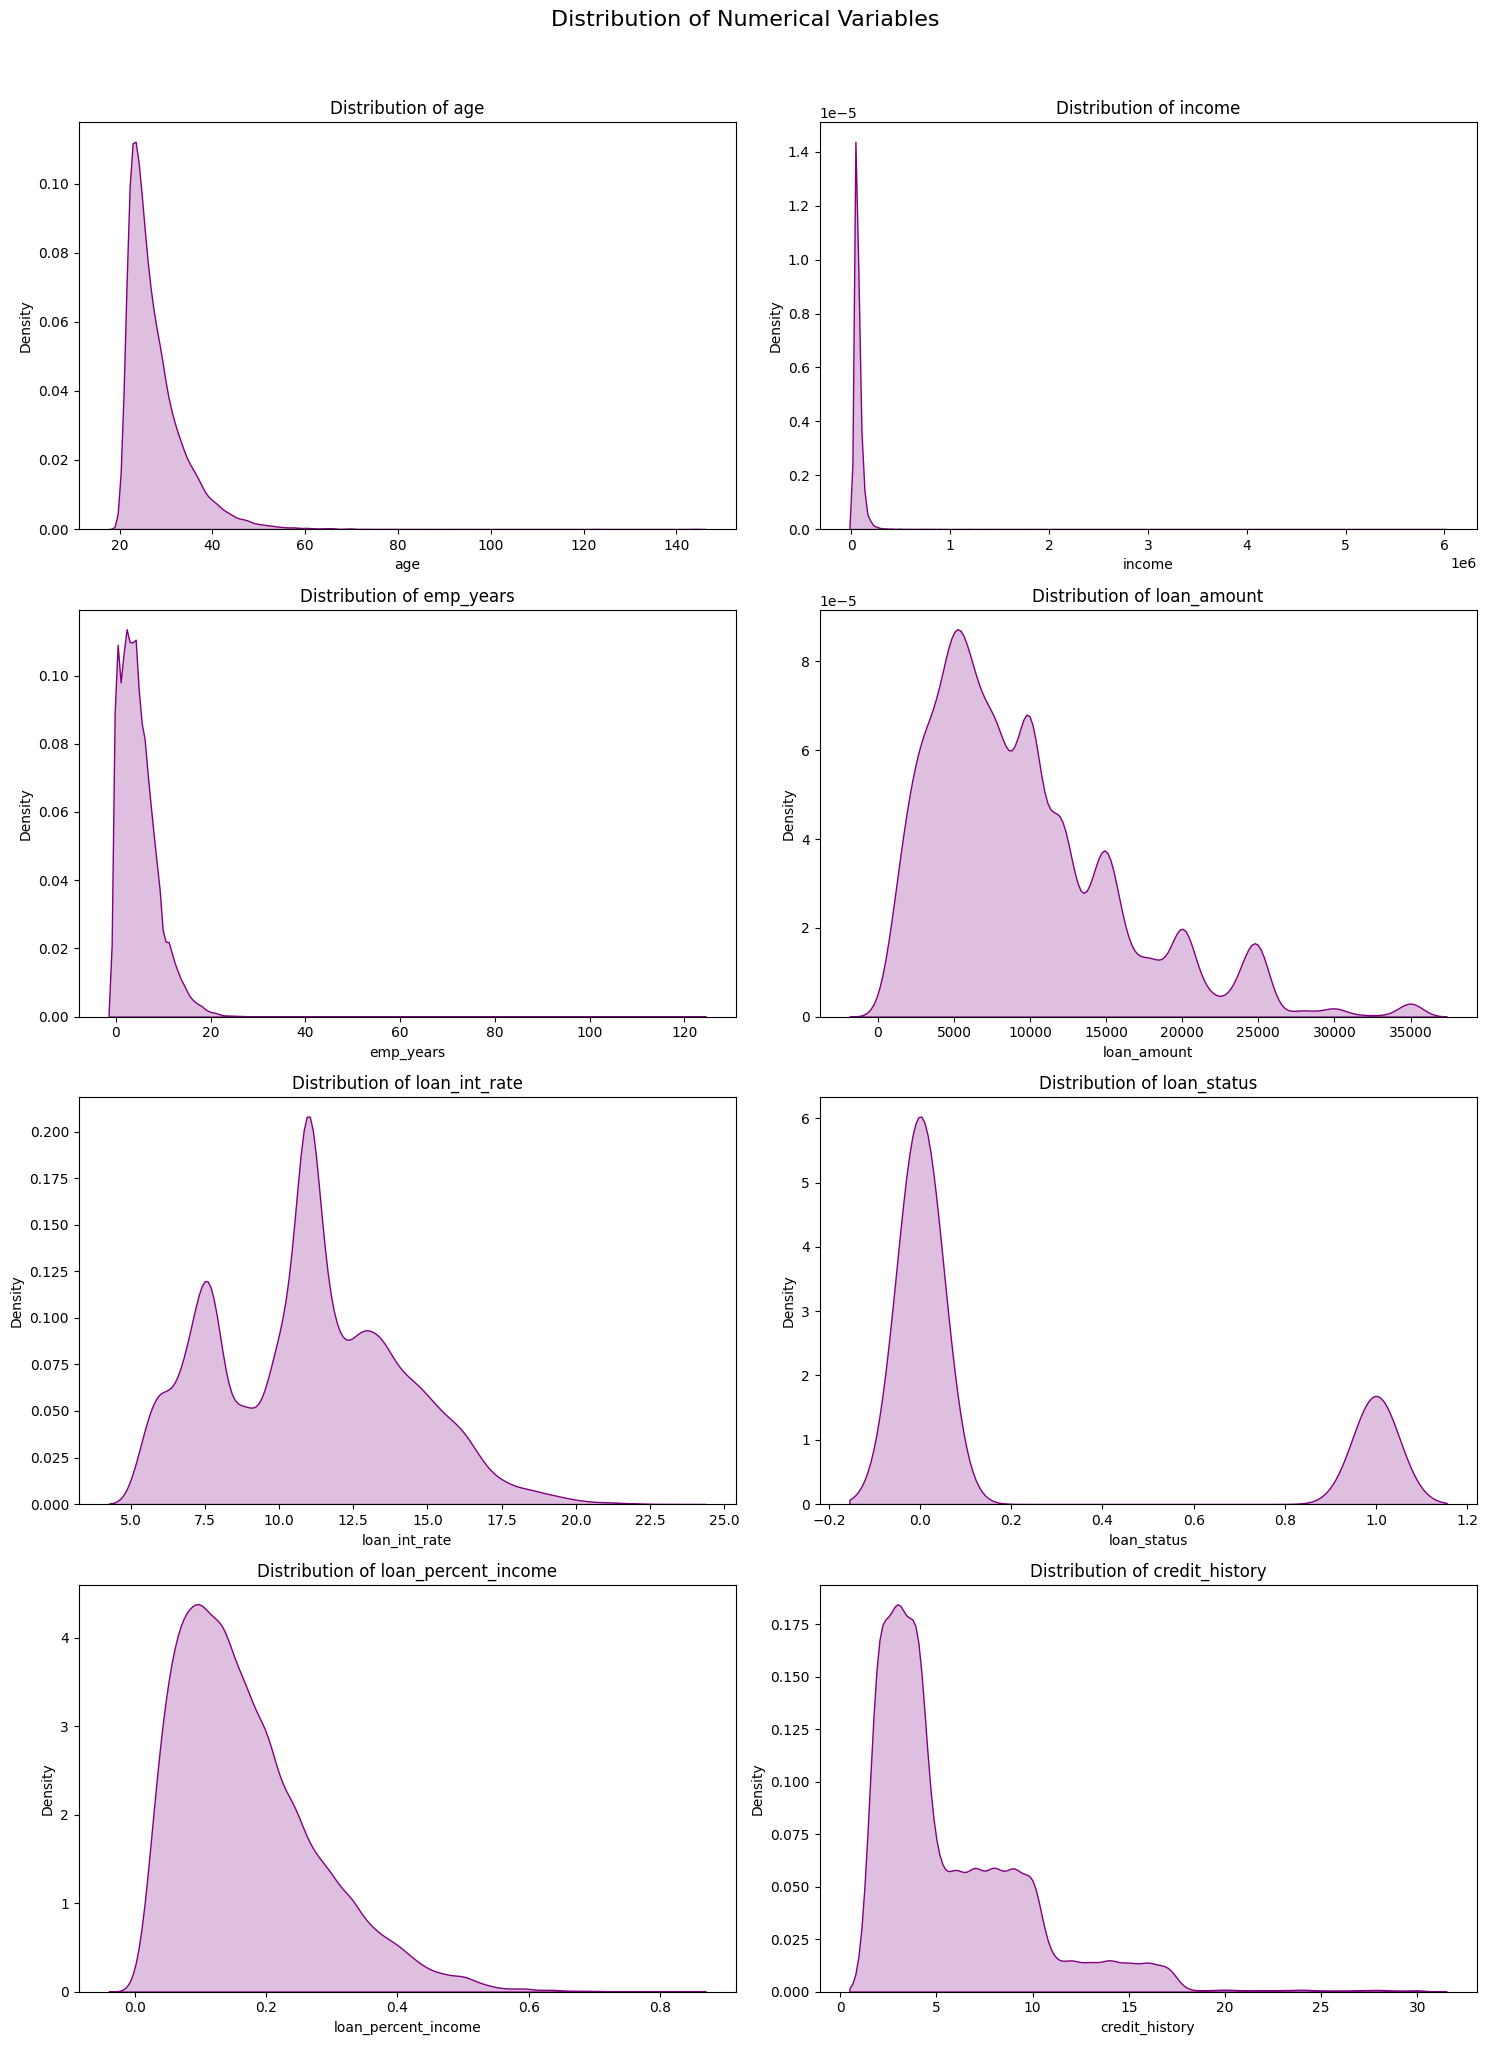

In [21]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Set up the subplot grid
num_cols = len(numerical_columns)
fig, axes = plt.subplots(
    nrows=(num_cols + 1) // 2, ncols=2,
    figsize=(15, 5 * ((num_cols + 1) // 2))
    )
fig.suptitle("Distribution of Numerical Variables", fontsize=16, y=1.02)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot density plots for each numerical column
for i, col in enumerate(numerical_columns):
    sns.kdeplot(df[col], ax=axes[i], color='purple', fill=True)
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Density", fontsize=10)

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

# VISUALIZING DEFAULT DISTRIBUTION  
#### Donut Chart for Defaulters  

This step visualizes the distribution of defaulters in the `credit_default` column using a **donut chart**. The chart shows the proportion of defaulters vs. non-defaulters, making it easy to understand the balance (or imbalance) in the dataset. 

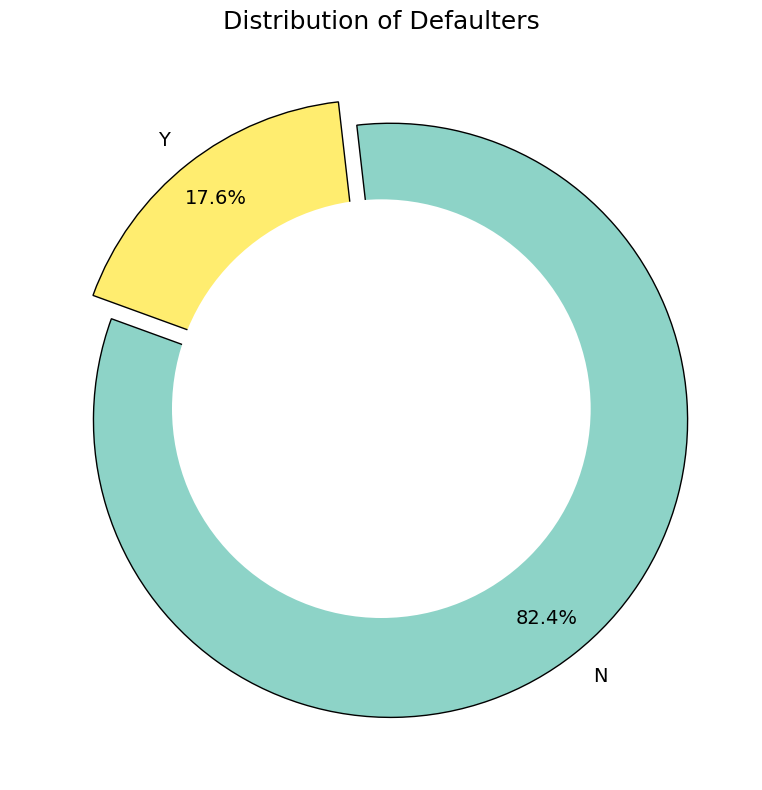

In [22]:
# Count the occurrences of each value in the 'credit_default' column
default_counts = df['credit_default'].value_counts()

# Get colors from the 'Set2' colormap
set2_colors = cm.get_cmap('Set3', len(default_counts))

# Plot a simplified donut chart
plt.figure(figsize=(8, 8))

# Explode the slices for a dynamic look
explode = (0.05, 0.05)  # Slightly separate the slices

# Plot the pie chart with custom styling
wedges, texts, autotexts = plt.pie(
    default_counts, 
    labels=default_counts.index, 
    autopct='%1.1f%%', 
    startangle=160, 
    pctdistance=0.85, 
    colors=set2_colors.colors, 
    textprops={'fontsize': 14,'color': 'black'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},  # Add edge styling
    explode=explode  # Explode the slices
)

# Draw a circle in the middle to make it a donut chart
circle = plt.Circle((0, 0), 0.70, color='white', fc='white', edgecolor='black', linewidth=2)
plt.gca().add_artist(circle)

# Add a title with custom styling
plt.title(
    'Distribution of Defaulters', 
    fontsize=18
)

# Improve layout and spacing
plt.tight_layout()

# Show the chart
plt.show()



### LOAN INTENT DISTRIBUTION

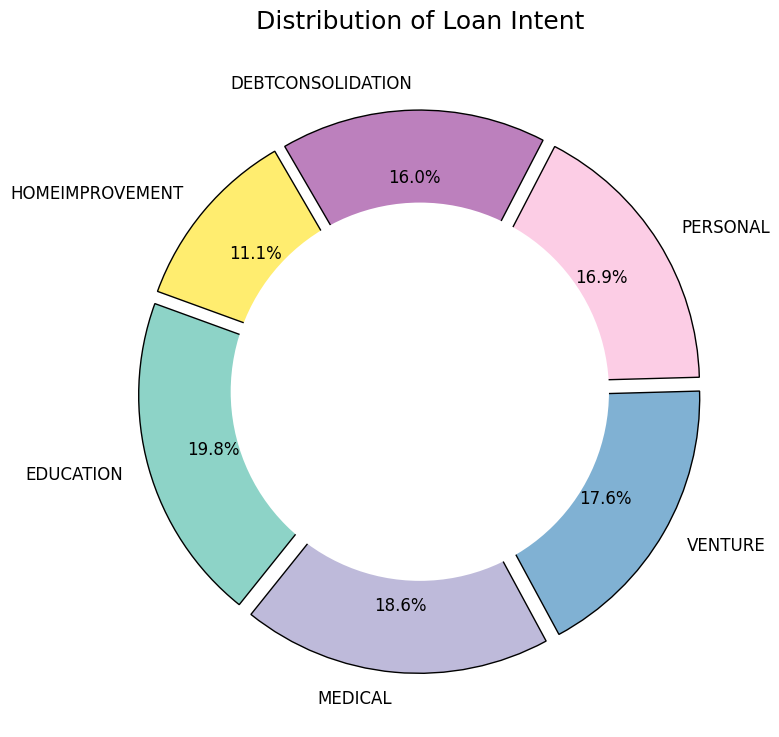

In [23]:
# Count the occurrences of each value in the 'loan_intent' column
intent_counts = df['loan_intent'].value_counts()

# Get colors from the 'Set3' colormap
set2_colors = plt.get_cmap('Set3', len(intent_counts))

# Plot a simplified donut chart
plt.figure(figsize=(8, 8))

# Explode the slices for a dynamic look
explode = [0.05] * len(intent_counts)  # Slightly separate all slices

# Plot the pie chart with custom styling
wedges, texts, autotexts = plt.pie(
    intent_counts, 
    labels=intent_counts.index, 
    autopct='%1.1f%%', 
    startangle=160, 
    pctdistance=0.75,  # Adjust percentage label distance
    colors=set2_colors.colors, 
    textprops={'fontsize': 12, 'color': 'black'},  # Adjust font size
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},  # Add edge styling
    explode=explode  # Explode the slices
)

# Draw a circle in the middle to make it a donut chart
circle = plt.Circle((0, 0), 0.70, color='white', fc='white', edgecolor='black', linewidth=2)
plt.gca().add_artist(circle)

# Add a title with custom styling
plt.title('Distribution of Loan Intent', fontsize=18, pad=20)

# Improve layout and spacing
plt.tight_layout()

# Show the chart
plt.show()

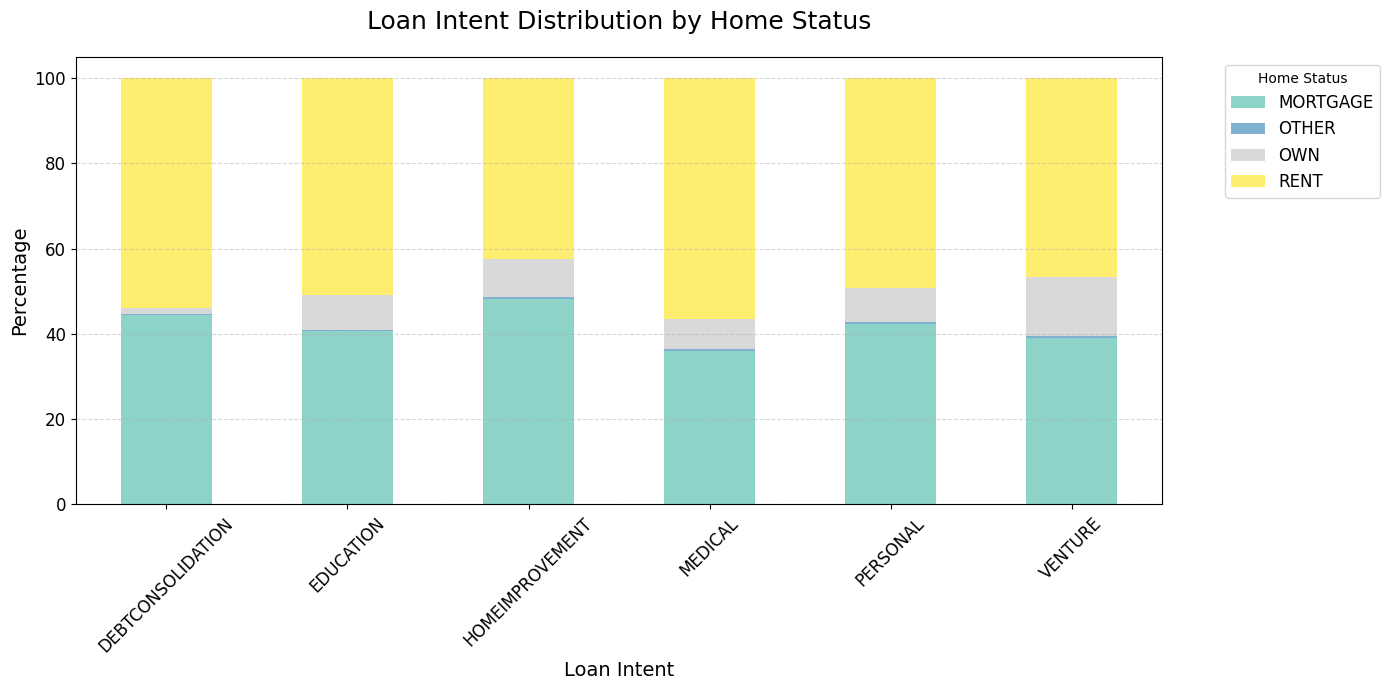

In [24]:
# Group the data by 'loan_intent' and 'home_status', and count the occurrences
grouped_df = df.groupby(['loan_intent', 'home_status']).size().unstack(fill_value=0)

# Normalize the data to get percentages
percent = grouped_df.div(grouped_df.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = percent.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='Set3')

# Customize the plot
plt.title('Loan Intent Distribution by Home Status', fontsize=18, pad=20)
plt.xlabel('Loan Intent', fontsize=14)
plt.ylabel('Percentage', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Home Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)  # Adjust legend position
plt.grid(axis='y', linestyle='--', alpha=0.5)  # Add grid lines for better readability
plt.tight_layout()

# Show the plot
plt.show()

# EXPLORING LOAN PATTERNS
### Relationship between Loan Amount and Loan Interest Rate
#### Scatter Plot with Marginal Distributions  

This visualization uses a **scatter plot with marginal distributions** to explore the relationship between loan amounts and loan interest rates, segmented by default status (`credit_default`). The scatter plot shows the distribution of loans, while the marginal histograms (or KDEs) provide additional context by displaying the distribution of loan amounts and interest rates separately.

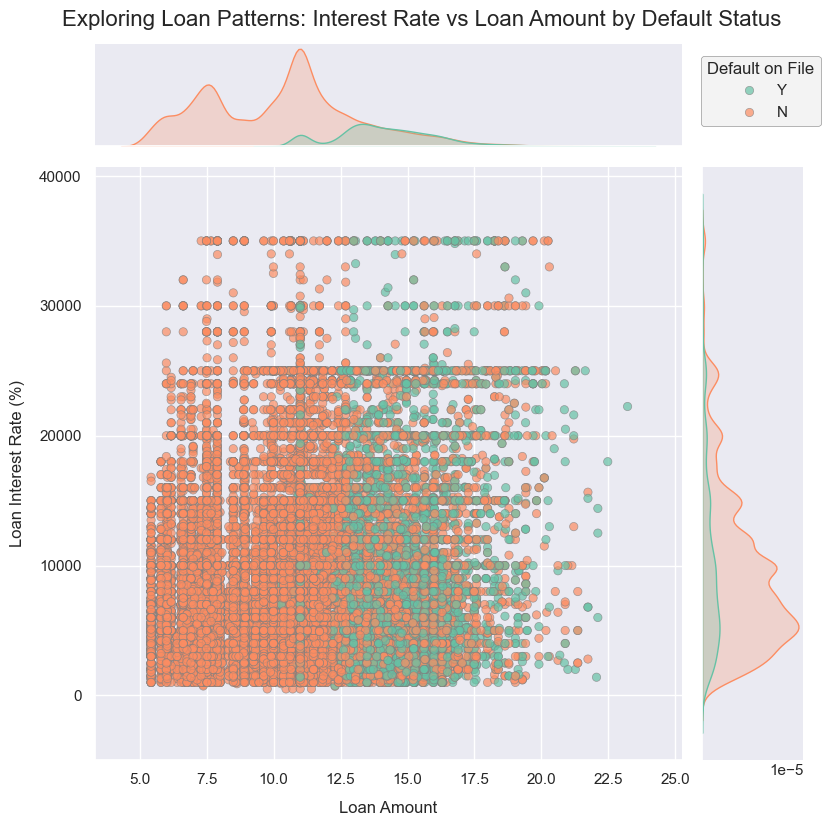

In [25]:
# Set seaborn theme to "whitegrid" for a cleaner look
sns.set_theme(style="darkgrid")

# Create a scatter plot with marginal distributions
plot = sns.jointplot(
    data=df,
    y='loan_amount',  # Loan Amount on X-axis
    x='loan_int_rate',  # Loan Interest Rate on Y-axis
    hue="credit_default",  # Different colors for 'Y' and 'N'
    palette="Set2",  # Use Set2 color palette for a softer and visually appealing scheme
    kind="scatter",  # Scatter plot as the main plot
    height=8,  # Control plot size
    alpha=0.7,  # Add transparency to points
    edgecolor='gray',  # Softer edge color
    linewidth=0.5  # Adjust edge line width
)

# Customize axis labels
plot.ax_joint.set_xlabel("Loan Amount", fontsize=12, labelpad=10)
plot.ax_joint.set_ylabel("Loan Interest Rate (%)", fontsize=12, labelpad=10)

# Add main title with spacing and formatting
plot.fig.suptitle(
    "Exploring Loan Patterns: Interest Rate vs Loan Amount by Default Status",
    y=1.02, fontsize=16
)

# Customize legend for better visibility
legend = plot.ax_joint.legend(title="Default on File", bbox_to_anchor=(1.02, 1.2), loc='upper left')
legend.get_frame().set_edgecolor('gray')  # Add border to the legend
legend.get_frame().set_linewidth(0.5)  # Make border line thicker
legend.get_frame().set_facecolor('#f0f0f0')  # Light gray background for subtle contrast

# Enhance marginal plots
plot.ax_marg_x.grid(False)  # Disable grid on marginal x
plot.ax_marg_y.grid(False)  # Disable grid on marginal y
plot.ax_marg_x.tick_params(axis='x', length=0)  # Hide x-axis ticks
plot.ax_marg_y.tick_params(axis='y', length=0)  # Hide y-axis ticks

# Adjust layout for better display
plt.tight_layout()
plt.show()



### Key Insights:


## Correlation Matrix

a **correlation matrix** to visualize relationships between numerical variables in the dataset. It helps identify:

1. **Strong positive or negative correlations** between features.
2. **Multicollinearity** (high correlation between independent variables).
3. **Relevance of features** to the target variable (if included).

In short, it’s a tool for understanding relationships and guiding feature selection in data analysis or modeling.

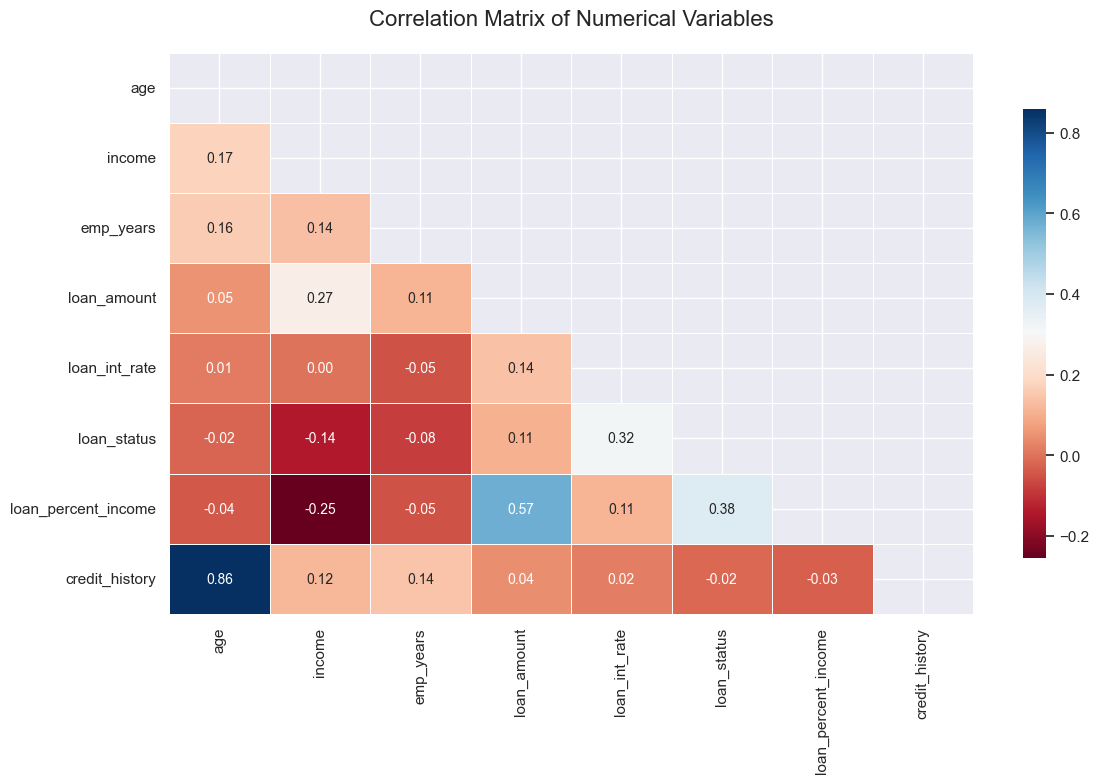

In [26]:
# Set up the figure size for better readability
plt.figure(figsize=(12, 8))

# Calculate the correlation matrix for numerical variables
corr = df.select_dtypes(include=['float64', 'int64']).corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Fill the upper triangle with NaN (or any other value, e.g., 0)
corr_masked = corr.mask(mask)

# Create a heatmap using the 'RdBu' color scheme
sns.heatmap(
    corr_masked,  # Use the masked correlation matrix
    annot=True, # Display correlation values in each cell
    cmap='RdBu', # Use the Red-Blue color scheme
    fmt='.2f', # Format correlation values to two decimal places
    linewidths=0.5, # Add thin lines between cells for better separation
    annot_kws={"size": 10}, # Set the font size for annotations
    cbar_kws={"shrink": 0.8} # Adjust the size of the colorbar
)

# Add a title to the heatmap for context
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, pad=20)

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Display the heatmap
plt.show()

# MAPPING TARGET VARIABLE FOR MACHINE LEARNING  
#### Preparing the 'credit_default' Column  

In this step, the `credit_default` column is mapped to numerical values to prepare it as the target variable for machine learning. The mapping is as follows:  
- `Y` (Yes) → `1` (Defaulters)  
- `N` (No) → `0` (Non-defaulters)  

This transformation is essential because most machine learning algorithms require numerical input for the target variable. After mapping, the distribution of the target variable is checked to ensure the transformation was successful and to verify the balance (or imbalance) of the dataset. 

In [27]:
# Map 'Y' to 1 and 'N' to 0 in the 'credit_default' column
df['credit_default'] = df['credit_default'].map({'Y': 1, 'N': 0})

# Verify the mapping
print(df['credit_default'].value_counts())


credit_default
0    26836
1     5745
Name: count, dtype: int64


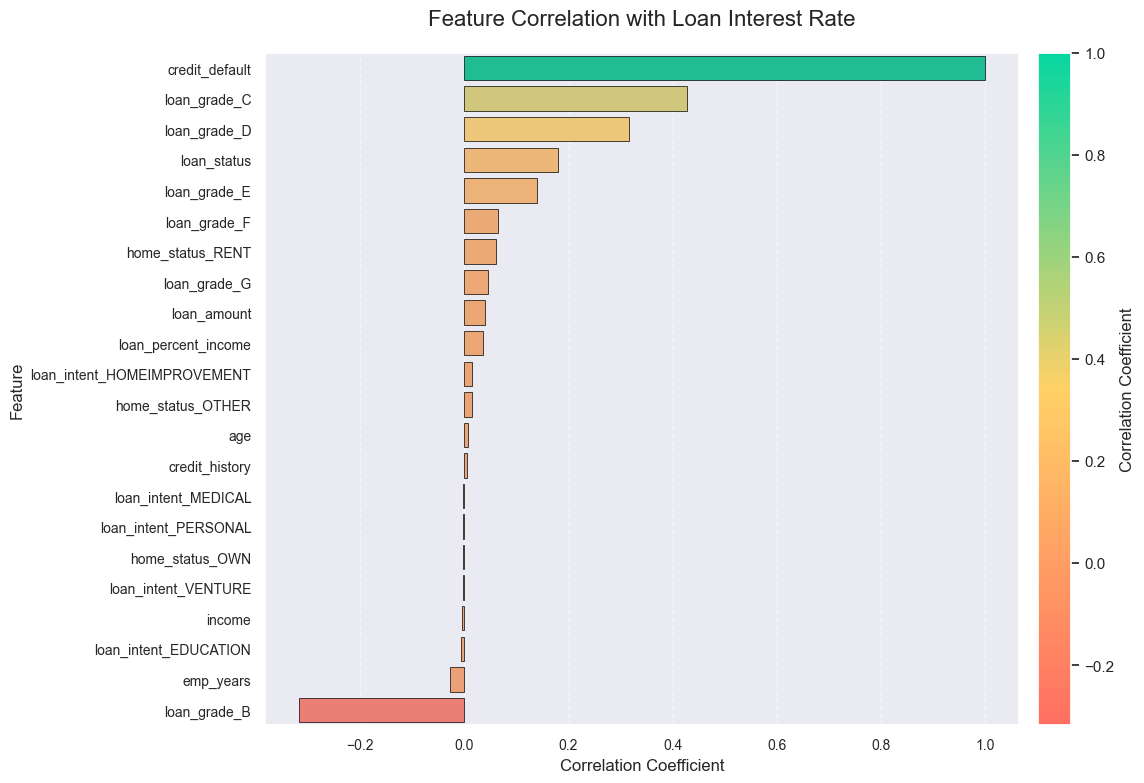

In [31]:
# Convert the Series to a DataFrame for better handling
credit_default_corr_df = credit_default_corr.reset_index()
credit_default_corr_df.columns = ['Feature', 'Coefficient']

# Remove 'loan_int_rate' from the DataFrame
credit_default_corr_df = credit_default_corr_df[credit_default_corr_df['Feature'] != 'loan_int_rate']

# Create a horizontal bar plot with custom colors and annotations
plt.figure(figsize=(12, 8))

# Define a custom color scale based on the coefficients
cmap = mcolors.LinearSegmentedColormap.from_list('Custom', ['#FF6F61', '#FFD166', '#06D6A0'])  # Red to green gradient
norm = plt.Normalize(credit_default_corr_df['Coefficient'].min(), credit_default_corr_df['Coefficient'].max())
colors = cmap(norm(credit_default_corr_df['Coefficient']))

# Plot horizontal bars with color mapping
bars = sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=credit_default_corr_df, 
    palette=colors, 
    edgecolor='black', 
    linewidth=0.5
)

# Add a colorbar for reference
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, orientation='vertical', pad=0.02, ax=plt.gca())
cbar.set_label('Correlation Coefficient', fontsize=12)

# Customize the plot
plt.title('Feature Correlation with Loan Interest Rate', fontsize=16, pad=20)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)  # Add grid lines for better readability

# Show the plot
plt.tight_layout()
plt.show()

# MACHINE LEARNING SETUP  
#### Defining Feature and Target Variables  

In this step, the feature and target variables are defined for the machine learning model. The selected features are chosen **intuitively** based on their potential to influence the target variable, even if they are not the most strongly correlated with it.  

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier  # or any model

# Identify column types
categorical_cols = ['home_status', 'loan_intent', 'loan_grade']

numeric_cols = ['income',
                'emp_years',
                'loan_amount',
                'loan_status', 
                'loan_int_rate',
                'credit_history',
                'loan_percent_income'
                ]

# Split your data
X = df[categorical_cols + numeric_cols]
y = df['credit_default']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing for each type
### run OneHotEncoder on the categorical variables
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[("cat", ohe, categorical_cols),
    ("num", StandardScaler(), numeric_cols)]
    )



RandomForestClassifier

In [ ]:
# pipeline
rf_model_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Fit the model
rf_model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


LogisticRegression

In [ ]:

# pipeline
lg_model_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit the model
lg_model_pipeline.fit(X, y)


,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


XGBClassifier

In [ ]:
from xgboost import XGBClassifier
# pipeline
xgb_model_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# Fit the model
xgb_model_pipeline.fit(X, y)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


SVC

In [47]:
from sklearn.svm import SVC

svc_model_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', SVC(kernel='rbf', probability=True))
])

# Fit the model
svc_model_pipeline.fit(X, y)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
# Access the trained classifier
regression = lg_model_pipeline.named_steps["classifier"]

# Print coefficients and intercept
print(" Regression Model Parameters ".center(50, "="))
print(f"intercept: {regression.intercept_}")
print("-" * 50)
print(f"coefficients: {regression.coef_}")

========== Regression Model Parameters ===========
intercept: [-5.70058221]
--------------------------------------------------
coefficients: [[ 2.16203153e-01  5.07920258e-02 -9.29366346e-03 -8.17428759e-02
   3.62025057e-03 -2.09065001e-02 -1.37106013e-03  3.30508959e-02
  -2.62864598e+00  5.64357487e+00  5.61917088e+00  5.40600625e+00
   5.24964902e+00  5.20594387e+00 -3.59265097e-03 -8.47510353e-04
   1.15774074e-02  8.79686660e-03  1.21035655e-01 -2.15055148e-02
  -5.34419169e-02]]


In [49]:
# Get feature names after OHE + scaling
ohe = rf_model_pipeline.named_steps['preprocessing'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_cols)
all_features = np.concatenate([numeric_cols, ohe_features])

# Create a DataFrame of coefficients
coef_df = pd.DataFrame(regression.coef_[0], index=all_features, columns=['Coefficient'])
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False)

# Display the features
print("\nTop Features by Coefficient:\n")
print(coef_df_sorted.head(20))


Top Features by Coefficient:

                             Coefficient
home_status_RENT                5.643575
loan_intent_EDUCATION           5.619171
loan_intent_HOMEIMPROVEMENT     5.406006
loan_intent_MEDICAL             5.249649
loan_intent_PERSONAL            5.205944
income                          0.216203
loan_grade_E                    0.121036
emp_years                       0.050792
home_status_OTHER               0.033051
loan_grade_C                    0.011577
loan_grade_D                    0.008797
loan_int_rate                   0.003620
loan_grade_B                   -0.000848
loan_percent_income            -0.001371
loan_intent_VENTURE            -0.003593
loan_amount                    -0.009294
credit_history                 -0.020907
loan_grade_F                   -0.021506
loan_grade_G                   -0.053442
loan_status                    -0.081743


In [50]:
# Example input sample in original form (dict or DataFrame)
sample = {
    'income': 59000,
    'home_status': 'RENT',
    'emp_years': 123.0,
    'loan_intent': 'PERSONAL',
    'loan_grade': 'D',
    'loan_amount': 35000,
    'loan_int_rate': 16.02,
    'loan_status': 1,
    'loan_percent_income': 0.59,
    'credit_history': 3
}

import pandas as pd
input_df = pd.DataFrame([sample])

# Predict
prediction = lg_model_pipeline.predict(input_df)
print("Predicted Credit Default:", prediction[0])


Predicted Credit Default: 0


In [51]:
# Folder structure
# .
# ├── ml_pipeline.py
# ├── main.py
# ├── Dockerfile
# ├── requirements.txt
# ├── .gitignore
# ├── .github/workflows/ci.yml

# =======================
# ml_pipeline.py
# =======================
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
import pandas as pd

def build_pipeline(categorical_cols, numeric_cols):
    preprocessor = ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ])
    model_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    return model_pipeline

def train_and_evaluate(df, target_col, categorical_cols, numeric_cols):
    X = df[categorical_cols + numeric_cols]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    pipeline = build_pipeline(categorical_cols, numeric_cols)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

    joblib.dump(pipeline, "model.joblib")
    return pipeline

# =======================
# main.py
# =======================
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()
model = joblib.load("model.joblib")

@app.get("/")
def read_root():
    return {"message": "Credit Risk Prediction API"}

@app.post("/predict")
def predict(data: dict):
    df = pd.DataFrame([data])
    prediction = model.predict(df)[0]
    proba = model.predict_proba(df)[0][1]
    return {
        "prediction": int(prediction),
        "default_probability": round(proba, 4)
    }

# =======================
# Dockerfile
# =======================
FROM python:3.10-slim
WORKDIR /app
COPY requirements.txt requirements.txt
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]

# =======================
# requirements.txt
# =======================
fastapi
uvicorn
scikit-learn
joblib
pandas

# =======================
# .gitignore
# =======================
__pycache__/
*.pyc
*.pkl
*.joblib
.env

# =======================
# .github/workflows/ci.yml
# =======================
name: CI

on:
  push:
    branches: [ main ]

jobs:
  build:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: '3.10'
      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt
      - name: Run basic pipeline check
        run: |
          echo "Running dummy test"
          python -c "import joblib; print('Test passed')"


SyntaxError: invalid syntax (346505940.py, line 79)